## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [1]:
# import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('shopping_trends.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
# check the dataset size with df.shape
df.shape

(3900, 19)

In [4]:
# drop the Customer ID column
df = df.drop(columns=['Customer ID'])
df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [ ]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   str    
 2   Item Purchased            3900 non-null   str    
 3   Category                  3900 non-null   str    
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   str    
 6   Size                      3900 non-null   str    
 7   Color                     3900 non-null   str    
 8   Season                    3900 non-null   str    
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   str    
 11  Payment Method            3900 non-null   str    
 12  Shipping Type             3900 non-null   str    
 13  Discount Applied          3900 non-null   str    
 14  Promo Code Used    

In [ ]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [ ]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [ ]:
# TODO: univariate — describe numeric columns
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [9]:
# split the data into male_df and female_df using df[df['Gender']==...]
male_df = df[df['Gender'] == 'Male'].copy()
female_df = df[df['Gender'] == 'Female'].copy()

male_df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


## **EDA**

### **Item Purchased**

In [10]:
# count top items with value_counts().reset_index() for male, female, and all customers
all_items = df['Item Purchased'].value_counts().reset_index()
all_items.columns = ['Item Purchased', 'count']

male_items = male_df['Item Purchased'].value_counts().reset_index()
male_items.columns = ['Item Purchased', 'count']

female_items = female_df['Item Purchased'].value_counts().reset_index()
female_items.columns = ['Item Purchased', 'count']

all_items.head(10)

,Item Purchased,count
0,Blouse,171
1,Pants,171
2,Jewelry,171
3,Shirt,169
4,Dress,166
5,Sweater,164
6,Jacket,163
7,Coat,161
8,Sunglasses,161
9,Belt,161


C:\Users\TRUONG\AppData\Local\Temp\ipykernel_2756\322646964.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_items.head(10), y='Item Purchased', x='count', palette='viridis')


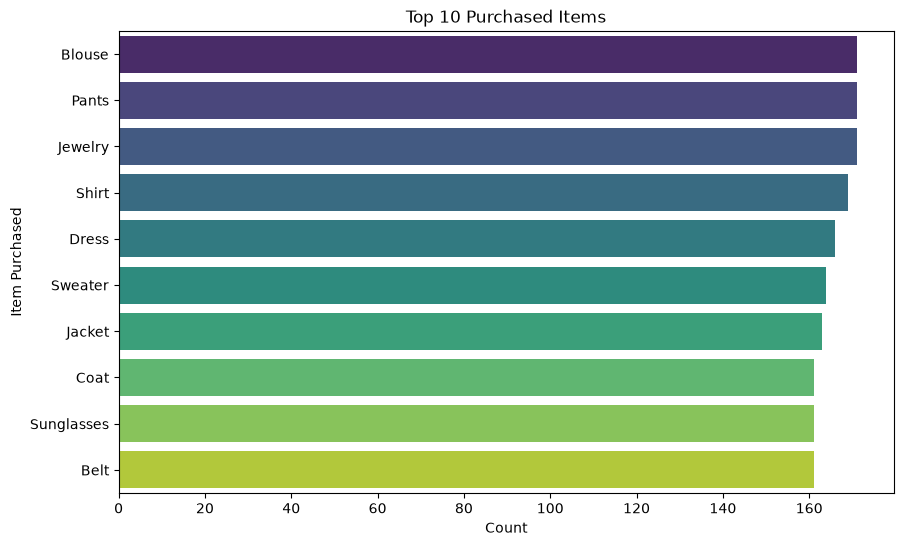

In [11]:
# plot a horizontal bar chart of the top 10 items with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(data=all_items.head(10), y='Item Purchased', x='count', palette='viridis')
plt.title('Top 10 Purchased Items')
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

C:\Users\TRUONG\AppData\Local\Temp\ipykernel_2756\1891462943.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=male_items.head(10), y='Item Purchased', x='count', palette='Blues_d')


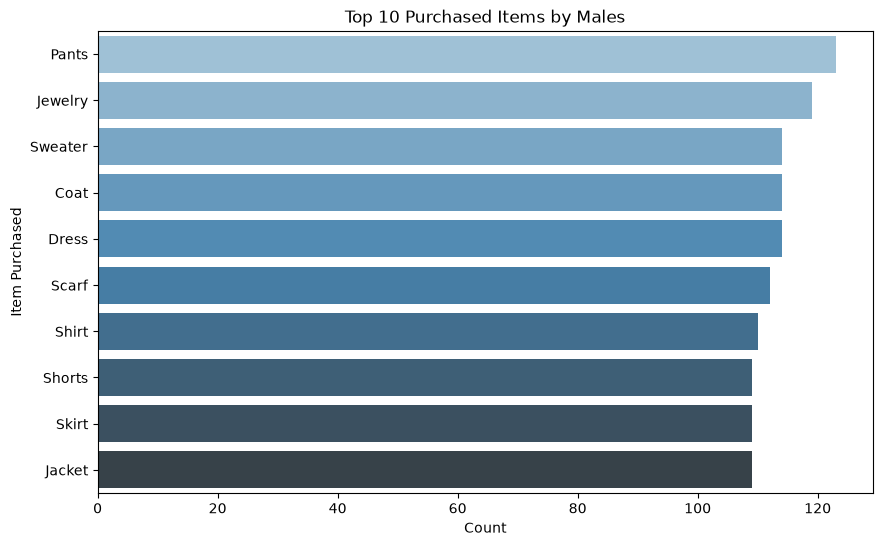

In [12]:
# plot a horizontal bar chart of the top 10 items for males with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(data=male_items.head(10), y='Item Purchased', x='count', palette='Blues_d')
plt.title('Top 10 Purchased Items by Males')
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

C:\Users\TRUONG\AppData\Local\Temp\ipykernel_2756\1560016140.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=female_items.head(10), y='Item Purchased', x='count', palette='Reds_d')


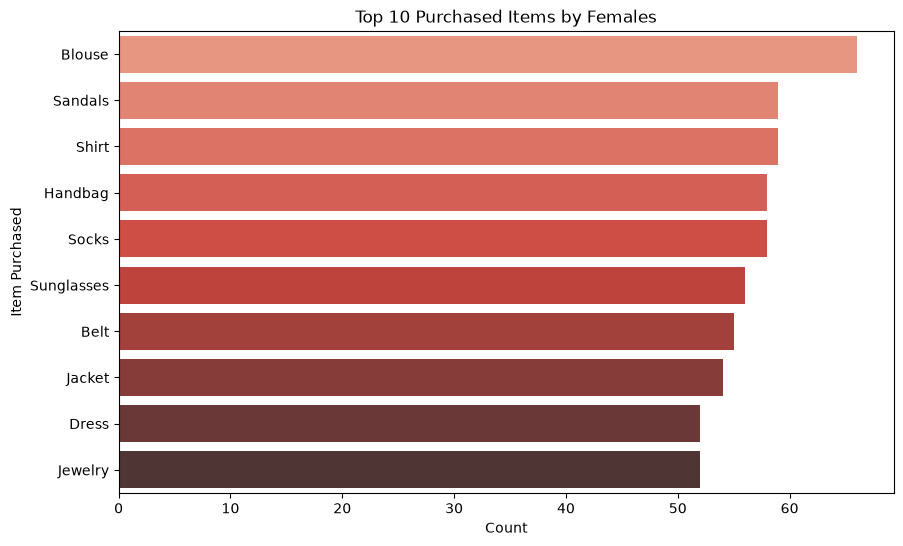

In [13]:
# plot a horizontal bar chart of the top 10 items for females with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(data=female_items.head(10), y='Item Purchased', x='count', palette='Reds_d')
plt.title('Top 10 Purchased Items by Females')
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

In [14]:
# count Size with value_counts() for all customers
size_counts = df['Size'].value_counts().reset_index()
size_counts.columns = ['Size', 'count']
size_counts

,Size,count
0,M,1755
1,L,1053
2,S,663
3,XL,429


In [15]:
# count Size with value_counts() for male_df and female_df
size_counts_m = male_df['Size'].value_counts().reset_index()
size_counts_m.columns = ['Size', 'count']

size_counts_f = female_df['Size'].value_counts().reset_index()
size_counts_f.columns = ['Size', 'count']

size_counts_m, size_counts_f

(  Size  count
 0    M   1165
 1    L    716
 2    S    476
 3   XL    295,
   Size  count
 0    M    590
 1    L    337
 2    S    187
 3   XL    134)

### **Category**

In [16]:
# count Category with value_counts().reset_index() for all customers
ctg = df['Category'].value_counts().reset_index()
ctg.columns = ['Category', 'count']
ctg

,Category,count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


In [17]:
# count Category with value_counts().reset_index() for male_df and female_df
ctg_m = male_df['Category'].value_counts().reset_index()
ctg_m.columns = ['Category', 'count']

ctg_f = female_df['Category'].value_counts().reset_index()
ctg_f.columns = ['Category', 'count']

ctg_m, ctg_f

(      Category  count
 0     Clothing   1181
 1  Accessories    848
 2     Footwear    400
 3    Outerwear    223,
       Category  count
 0     Clothing    556
 1  Accessories    392
 2     Footwear    199
 3    Outerwear    101)

C:\Users\TRUONG\AppData\Local\Temp\ipykernel_2756\998027602.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ctg_m, x='Category', y='count', palette='Blues_d')


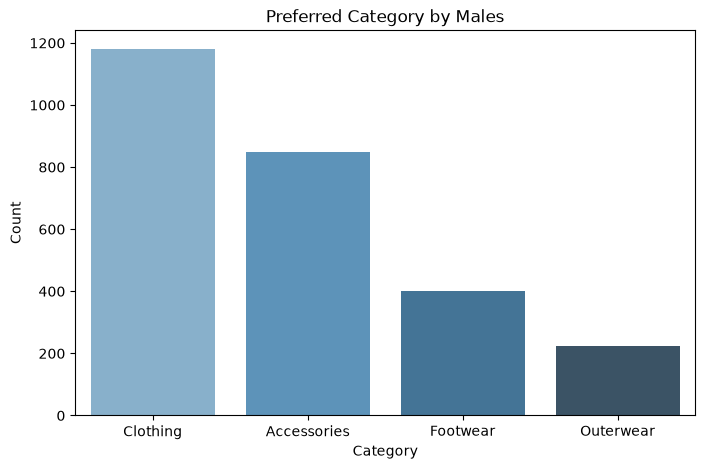

In [18]:
# plot a bar chart of preferred Category for males with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(data=ctg_m, x='Category', y='count', palette='Blues_d')
plt.title('Preferred Category by Males')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

C:\Users\TRUONG\AppData\Local\Temp\ipykernel_2756\252685443.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ctg_f, x='Category', y='count', palette='Reds_d')


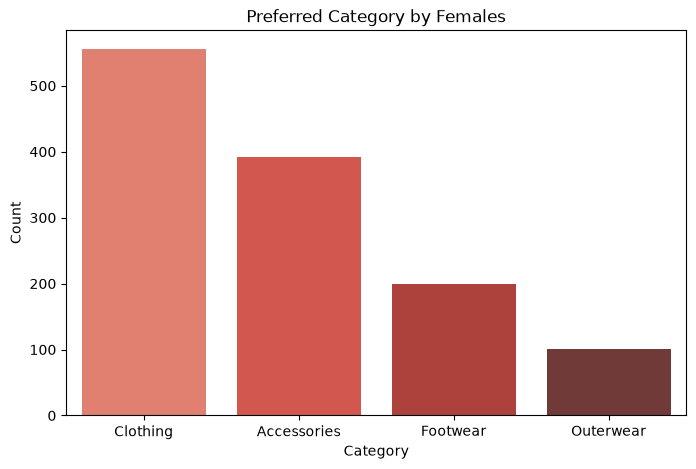

In [19]:
# plot a bar chart of preferred Category for females with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(data=ctg_f, x='Category', y='count', palette='Reds_d')
plt.title('Preferred Category by Females')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

C:\Users\TRUONG\AppData\Local\Temp\ipykernel_2756\2879722106.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ctg, x='Category', y='count', palette='Set2')


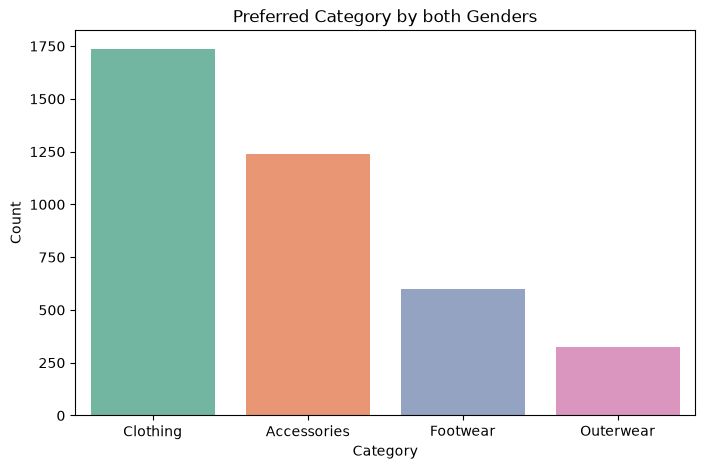

In [20]:
# plot a bar chart of preferred Category for both genders with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(data=ctg, x='Category', y='count', palette='Set2')
plt.title('Preferred Category by both Genders')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

In [21]:
# create waffle_data_m and waffle_data_f from Category value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())

waffle_data_m, waffle_data_f

({'Clothing': np.int64(1181),
  'Accessories': np.int64(848),
  'Footwear': np.int64(400),
  'Outerwear': np.int64(223)},
 {'Clothing': np.int64(556),
  'Accessories': np.int64(392),
  'Footwear': np.int64(199),
  'Outerwear': np.int64(101)})

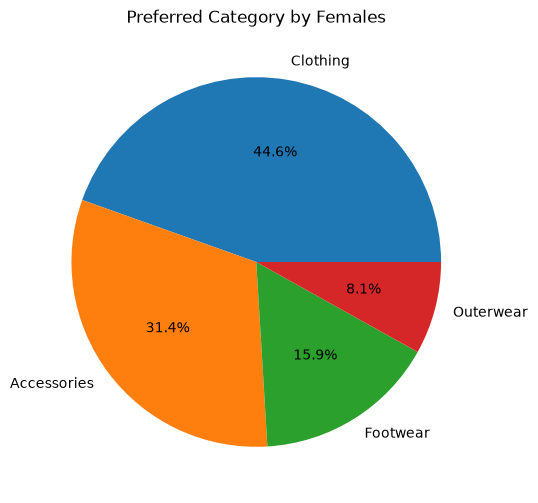

In [22]:
# plot a pie chart of preferred Category for females with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_f.values(),
    labels=waffle_data_f.keys(),
    autopct='%1.1f%%'
)
plt.title('Preferred Category by Females')
plt.show()

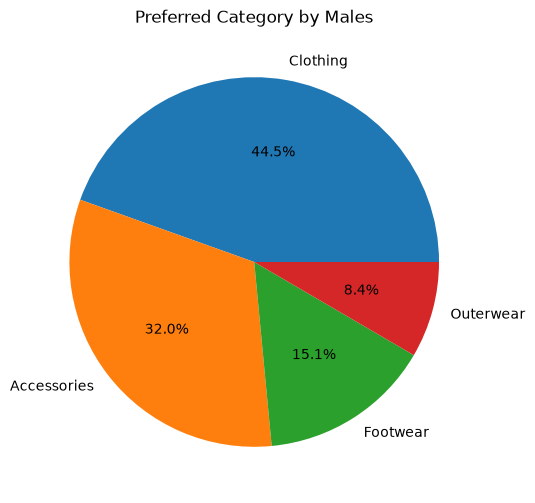

In [23]:
# plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)
plt.title('Preferred Category by Males')
plt.show()

### **Review ratings**

In [24]:
# filter female Clothing rows, then mean of Review Rating
cr_f = female_df[female_df['Category'] == 'Clothing']
avg_cr_f = cr_f['Review Rating'].mean()
cr_f.head(), avg_cr_f

(      Age  Gender Item Purchased  Category  Purchase Amount (USD)  \
 2652   23  Female         Shorts  Clothing                     20   
 2653   67  Female         Blouse  Clothing                     36   
 2656   52  Female         Shorts  Clothing                     76   
 2657   52  Female          Dress  Clothing                     81   
 2660   24  Female          Pants  Clothing                     85   
 
             Location Size     Color  Season  Review Rating  \
 2652        Maryland    L      Cyan  Summer            3.3   
 2653       Wisconsin    L  Lavender    Fall            4.8   
 2656         Indiana    L    Yellow  Winter            3.6   
 2657           Texas    M      Pink  Summer            2.7   
 2660  South Carolina    L    Yellow  Spring            4.9   
 
      Subscription Status Payment Method   Shipping Type Discount Applied  \
 2652                  No     Debit Card  2-Day Shipping               No   
 2653                  No    Credit Card    

In [25]:
# filter male Clothing rows, then mean of Review Rating
cr_m = male_df[male_df['Category'] == 'Clothing']
avg_cr_m = cr_m['Review Rating'].mean()
cr_m.head(), avg_cr_m

(   Age Gender Item Purchased  Category  Purchase Amount (USD)       Location  \
 0   55   Male         Blouse  Clothing                     53       Kentucky   
 1   19   Male        Sweater  Clothing                     64          Maine   
 2   50   Male          Jeans  Clothing                     73  Massachusetts   
 4   45   Male         Blouse  Clothing                     49         Oregon   
 6   63   Male          Shirt  Clothing                     85        Montana   
 
   Size      Color  Season  Review Rating Subscription Status Payment Method  \
 0    L       Gray  Winter            3.1                 Yes    Credit Card   
 1    L     Maroon  Winter            3.1                 Yes  Bank Transfer   
 2    S     Maroon  Spring            3.1                 Yes           Cash   
 4    M  Turquoise  Spring            2.7                 Yes           Cash   
 6    M       Gray    Fall            3.2                 Yes     Debit Card   
 
    Shipping Type Discount App

In [26]:
# avg_cr_m,avg_cr_f

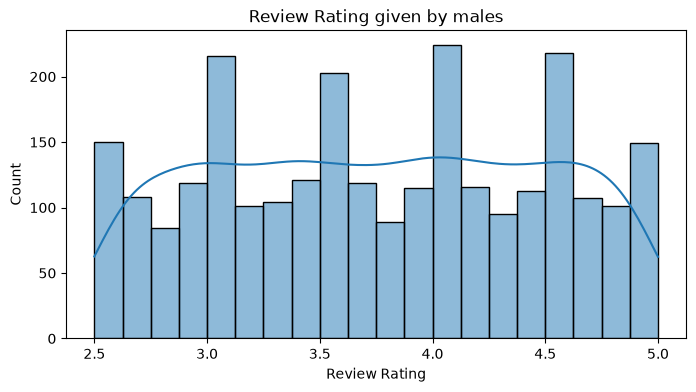

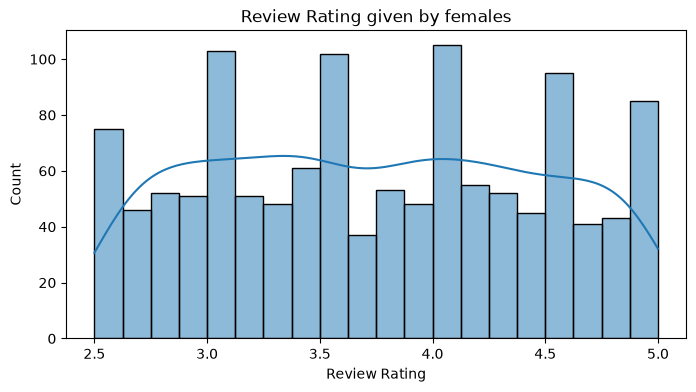

In [27]:
# plot Review Rating histograms for males and females with sns.histplot()
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20, kde=True)
plt.title('Review Rating given by males')
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20, kde=True)
plt.title('Review Rating given by females')
plt.show()

In [28]:
# count Review Rating with value_counts() for male Clothing (cr_m)
cr_m['Review Rating'].value_counts().sort_index()

Review Rating
2.5    17
2.6    45
2.7    55
2.8    41
2.9    55
3.0    49
3.1    46
3.2    41
3.3    49
3.4    59
3.5    48
3.6    46
3.7    61
3.8    39
3.9    52
4.0    52
4.1    48
4.2    52
4.3    45
4.4    43
4.5    36
4.6    46
4.7    46
4.8    46
4.9    48
5.0    16
Name: count, dtype: int64

### **Purchase Amount (USD)**

In [29]:
# sum Purchase Amount (USD) for males
m_tpa = male_df['Purchase Amount (USD)'].sum()

# sum Purchase Amount (USD) for females
f_tpa = female_df['Purchase Amount (USD)'].sum()

m_tpa, f_tpa

(np.int64(157890), np.int64(75191))

C:\Users\TRUONG\AppData\Local\Temp\ipykernel_2756\2897321596.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=spend_by_gender, x='Gender', y='Total Spend (USD)', palette='Set2')


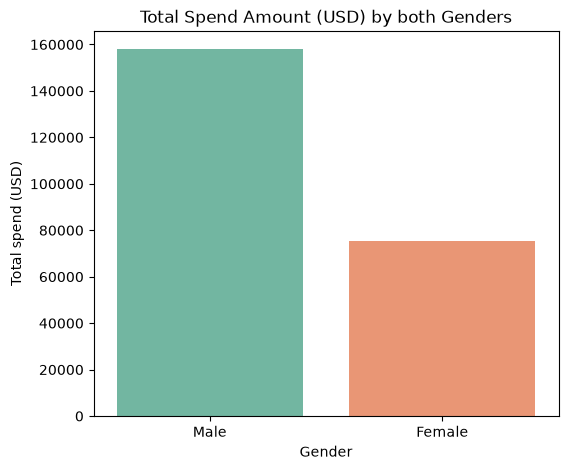

In [30]:
# plot total spend by gender with sns.barplot()
spend_by_gender = pd.DataFrame({
    'Gender': ['Male', 'Female'],
    'Total Spend (USD)': [m_tpa, f_tpa]
})

plt.figure(figsize=(6, 5))
sns.barplot(data=spend_by_gender, x='Gender', y='Total Spend (USD)', palette='Set2')
plt.title('Total Spend Amount (USD) by both Genders')
plt.ylabel('Total spend (USD)')
plt.show()

In [31]:
# filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = female_df[female_df['Category'] == 'Clothing']
ca_f = female_df[female_df['Category'] == 'Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']

cc_f.head(), ca_f.head(), cf_f.head(), co_f.head()

(      Age  Gender Item Purchased  Category  Purchase Amount (USD)  \
 2652   23  Female         Shorts  Clothing                     20   
 2653   67  Female         Blouse  Clothing                     36   
 2656   52  Female         Shorts  Clothing                     76   
 2657   52  Female          Dress  Clothing                     81   
 2660   24  Female          Pants  Clothing                     85   
 
             Location Size     Color  Season  Review Rating  \
 2652        Maryland    L      Cyan  Summer            3.3   
 2653       Wisconsin    L  Lavender    Fall            4.8   
 2656         Indiana    L    Yellow  Winter            3.6   
 2657           Texas    M      Pink  Summer            2.7   
 2660  South Carolina    L    Yellow  Spring            4.9   
 
      Subscription Status Payment Method   Shipping Type Discount Applied  \
 2652                  No     Debit Card  2-Day Shipping               No   
 2653                  No    Credit Card    

In [32]:
# filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = male_df[male_df['Category'] == 'Clothing']
ca_m = male_df[male_df['Category'] == 'Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']

cc_m.head(), ca_m.head(), cf_m.head(), co_m.head()

(   Age Gender Item Purchased  Category  Purchase Amount (USD)       Location  \
 0   55   Male         Blouse  Clothing                     53       Kentucky   
 1   19   Male        Sweater  Clothing                     64          Maine   
 2   50   Male          Jeans  Clothing                     73  Massachusetts   
 4   45   Male         Blouse  Clothing                     49         Oregon   
 6   63   Male          Shirt  Clothing                     85        Montana   
 
   Size      Color  Season  Review Rating Subscription Status Payment Method  \
 0    L       Gray  Winter            3.1                 Yes    Credit Card   
 1    L     Maroon  Winter            3.1                 Yes  Bank Transfer   
 2    S     Maroon  Spring            3.1                 Yes           Cash   
 4    M  Turquoise  Spring            2.7                 Yes           Cash   
 6    M       Gray    Fall            3.2                 Yes     Debit Card   
 
    Shipping Type Discount App

In [33]:
# create pcu dict from Promo Code Used value_counts()
pcu = df['Promo Code Used'].value_counts().to_dict()
pcu

{'No': 2223, 'Yes': 1677}

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

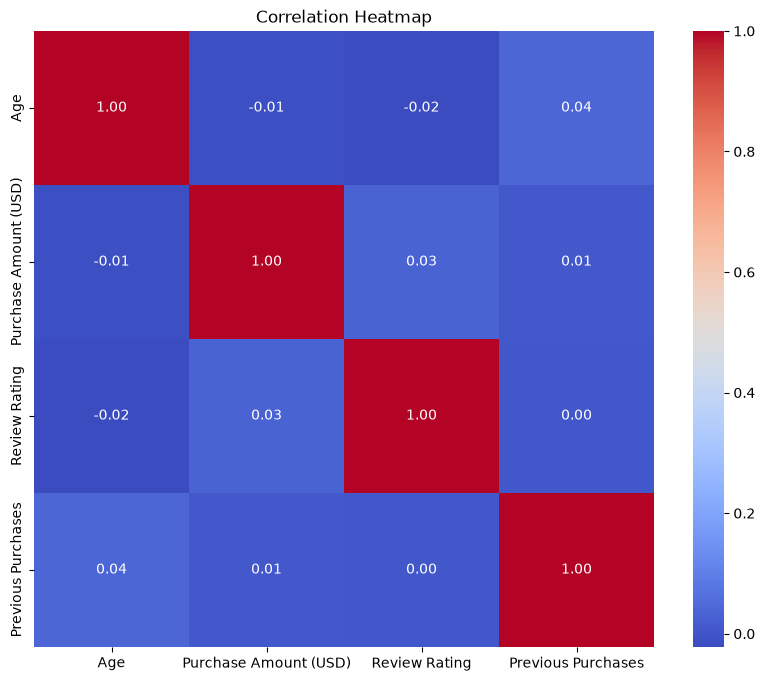

In [34]:
# compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [35]:
# dummy variables for Gender, Size, and Category with pd.get_dummies()
df = pd.get_dummies(df, columns=['Gender', 'Size', 'Category'], dtype=int)
df.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


In [36]:
# use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
# since sklearn is not available here, do the scaling manually

amount_min = df['Purchase Amount (USD)'].min()
amount_max = df['Purchase Amount (USD)'].max()
df['Amount_minmax'] = (df['Purchase Amount (USD)'] - amount_min) / (amount_max - amount_min)

age_mean = df['Age'].mean()
age_std = df['Age'].std(ddof=0)
df['Age_standard'] = (df['Age'] - age_mean) / age_std

df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [37]:
# use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
df['Amount_bin'] = pd.cut(df['Purchase Amount (USD)'], bins=3, labels=['Low', 'Medium', 'High'])
df['Amount_bin'].value_counts()

Amount_bin
Low       1345
High      1297
Medium    1258
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- 
- 
- 
- 

Caveat: correlation is not causation.